# Cascade Variants — Before vs After: C-order vs F-order `xi0` scratch buffer [code913.1]

Benchmarks the **before** and **after** implementations of `lfilter_forward_cascade_xi`
to measure the effect of allocating the `xi0` scratch buffer in F-order.

- **Before** (`gu133_before_impl`) — `xi0 = np.zeros(xi.shape)` — C-order, same size as `xi`
- **After** (`rec_lfilter`, production) — `xi0 = np.zeros((K + δ, N), order='F')` — F-order,
  larger buffer to accommodate signal shifting, then sliced back into `xi`

| # | Label | xi0 order | xi0 shape | Column-write pattern |
|---|-------|:---------:|:---------:|:--------------------:|
| 1 | Before | C (default) | (K, N) | strided |
| 2 | After | **F** | **(K+δ, N)** | **contiguous** |

> **Scope**: `AlssmPoly(poly_degree=1)`, forward segment `g=100`, K = 1 000 000 → **N = 2** states.
> Baseline `lm.profiling` of the N=2 model: **[code913.0](coding-code913.0-profile.ipynb)**.
> How these variants scale with ALSSM order N: **[code913.2](coding-code913.2-profile-higher-order.ipynb)**.
> Full pipeline before/after benchmark: **[code913.3](coding-code913.3-applied.ipynb)**.


In [4]:
import io, time, tracemalloc
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from numpy.linalg import inv, matrix_power as _mpow
from scipy.signal import lfilter as _scipy_lf
from line_profiler import LineProfiler
import lmlib as lm

lm.WARNING_NOT_STEADY_STATE = False

## Setup

Model and parameters shared by all four variants.

In [5]:
alssm    = lm.AlssmPoly(poly_degree=1)
seg_l    = lm.Segment(a=-21, b=-1, direction=lm.FW, g=100)
N_repeat = 20   # timing repetitions for line profiler

## Before vs After: C-order vs F-order `xi0`

Calls the actual `lfilter_forward_cascade_xi` from each implementation — no inline re-implementation.

| # | Variant | `xi0` order | `xi0` shape | Accumulation into `xi` |
|---|---------|:-----------:|:-----------:|:----------------------:|
| 1 | **Before** | C | (K, N) | `xi += xi0` (direct, same shape) |
| 2 | **After** | **F** | **(K+δ, N)** | `xi += xi0[slice]` (signal-shift corrected) |

`xi0` column write `xi0[:, n_]`:
- **C-order**: column stride = N × 8 = 16 B → strided, non-contiguous writes
- **F-order**: column stride = 8 B → single contiguous block per column


In [6]:
import importlib
import lmlib.statespace.backends.rec_lfilter as _rlf_mod
import gu133_before_impl as _before_mod
importlib.reload(_before_mod)

_A  = np.atleast_2d(alssm.A)   # (N, N) — force_MC=True path
_C  = np.atleast_2d(alssm.C)   # (1, N)
_bN = _A.shape[1]               # N = 2

K_4w  = 1_000_000
_y4w  = np.random.randn(K_4w, 1)  # (K, 1) — Q=1 observation, matches pipeline shape
_sw4w = np.ones(K_4w)              # unit sample weights

# Shared positional args (all but xi)
_cascade_kwargs = (_A, _C, seg_l.a, seg_l.b, seg_l.delta, seg_l.gamma, _y4w, _sw4w, 1.0)

# ── Before and after variant wrappers ────────────────────────────────────────

def variant_before(xi):
    """Before: C-order xi0 = np.zeros(xi.shape), xi += xi0."""
    _before_mod.lfilter_forward_cascade_xi(xi, *_cascade_kwargs)

def variant_after(xi):
    """After: F-order xi0 = np.zeros((K+δ, N), order='F'), xi += xi0[slice]."""
    _rlf_mod.lfilter_forward_cascade_xi(xi, *_cascade_kwargs)

# order = memory layout of xi passed in (matches xi_curr layout in rls.py)
# inner_fn = actual implementation for LineProfiler.add_function()
_4way = [
    ('Before (C-order xi0)', variant_before, 'C',
     _before_mod.lfilter_forward_cascade_xi),
    ('After  (F-order xi0)', variant_after,  'F',
     _rlf_mod.lfilter_forward_cascade_xi),
]

# Quick correctness check: both should produce the same xi output
_xi_b = np.zeros((K_4w, _bN), order='C')
_xi_a = np.zeros((K_4w, _bN), order='F')
variant_before(_xi_b)
variant_after(_xi_a)
print(f"Max diff before vs after: {np.max(np.abs(_xi_b - _xi_a)):.2e}  (should be ~0)")
print(f"K={K_4w:,}  N={_bN}  y.shape={_y4w.shape}")
print(f"Variants: {[v[0] for v in _4way]}")


Max diff before vs after: 0.00e+00  (should be ~0)
K=1,000,000  N=2  y.shape=(1000000, 1)
Variants: ['Before (C-order xi0)', 'After  (F-order xi0)']


## Line-by-line profile per variant

Uses `line_profiler.LineProfiler` to measure the time spent on **each line** of each variant.
Run at `K = 1 000 000` so timing differences are clearly visible.

In [7]:
N_lp4 = N_repeat

for vname, vfn, order, inner_fn in _4way:
    _xi_lp = np.zeros((K_4w, _bN), order=order)
    lp     = LineProfiler()
    lp.add_function(inner_fn)   # profile lines of the actual implementation
    lp_fn  = lp(vfn)            # entry-point wrapper

    for _ in range(N_lp4):
        _xi_lp[:] = 0
        lp_fn(_xi_lp)

    buf = io.StringIO()
    lp.print_stats(stream=buf, output_unit=1e-3 / N_lp4, stripzeros=True)
    print(f"\n{'═'*72}")
    print(f"  {vname}   —  {N_lp4} calls, Time = per-call average (ms)")
    print(f"{'═'*72}")
    print(buf.getvalue())



════════════════════════════════════════════════════════════════════════
  Before (C-order xi0)   —  20 calls, Time = per-call average (ms)
════════════════════════════════════════════════════════════════════════
Timer unit: 5e-05 s

Total time: 1.03822 s
File: /esat/biomeddata/pdevogel/projects/lmlib/coding/13-backend/gu133_before_impl.py
Function: lfilter_forward_cascade_xi at line 36

Line #      Hits         Time  Per Hit   % Time  Line Contents
    36                                           def lfilter_forward_cascade_xi(xi, A, C, a, b, delta, gamma, y, v, beta):
    37                                               """Before: C-order xi0 scratch buffer; xi += xi0 accumulation copy."""
    38        20          0.3      0.0      0.0      if not (a < 0 and b <= 0):
    39                                                   raise NotImplementedError('BACKEND: a and b has to be lower then zero for forward calculated segments.')
    40        20          0.6      0.0      0.0      gam

/tmp/ipykernel_1589527/1939146636.py:6: UserWarning: Adding a function with a `.__wrapped__` attribute. You may want to profile the wrapped function by adding `lfilter_forward_cascade_xi.__wrapped__` instead.



════════════════════════════════════════════════════════════════════════
  After  (F-order xi0)   —  20 calls, Time = per-call average (ms)
════════════════════════════════════════════════════════════════════════
Timer unit: 5e-05 s

Total time: 0.904906 s
File: /esat/biomeddata/pdevogel/projects/lmlib/lmlib/utils/profiling.py
Function: profile.<locals>.wrapper at line 163

Line #      Hits         Time  Per Hit   % Time  Line Contents
   163                                               @wraps(func)
   164                                               def wrapper(*args, **kwargs):
   165        20          0.3      0.0      0.0          if not _enabled:
   166        20      18097.8    904.9    100.0              return func(*args, **kwargs)
   167                                           
   168                                                   # Avoid stopping an outer tracemalloc session (nested @profile calls).
   169                                                   already_tra

## Wall-time benchmark

Pre-allocates a dedicated pool of `y_diff` copies per variant so the `copy()` overhead does not pollute the timed section. Bars show median ± min/max over `N_time = 20` runs.


Variant                                  median ms    min ms    max ms   speedup
──────────────────────────────────────────────────────────────────────────────
Before (C-order xi0)                         51.85     51.64     52.31     1.00×
After  (F-order xi0)                         45.00     44.91     45.31     1.15×


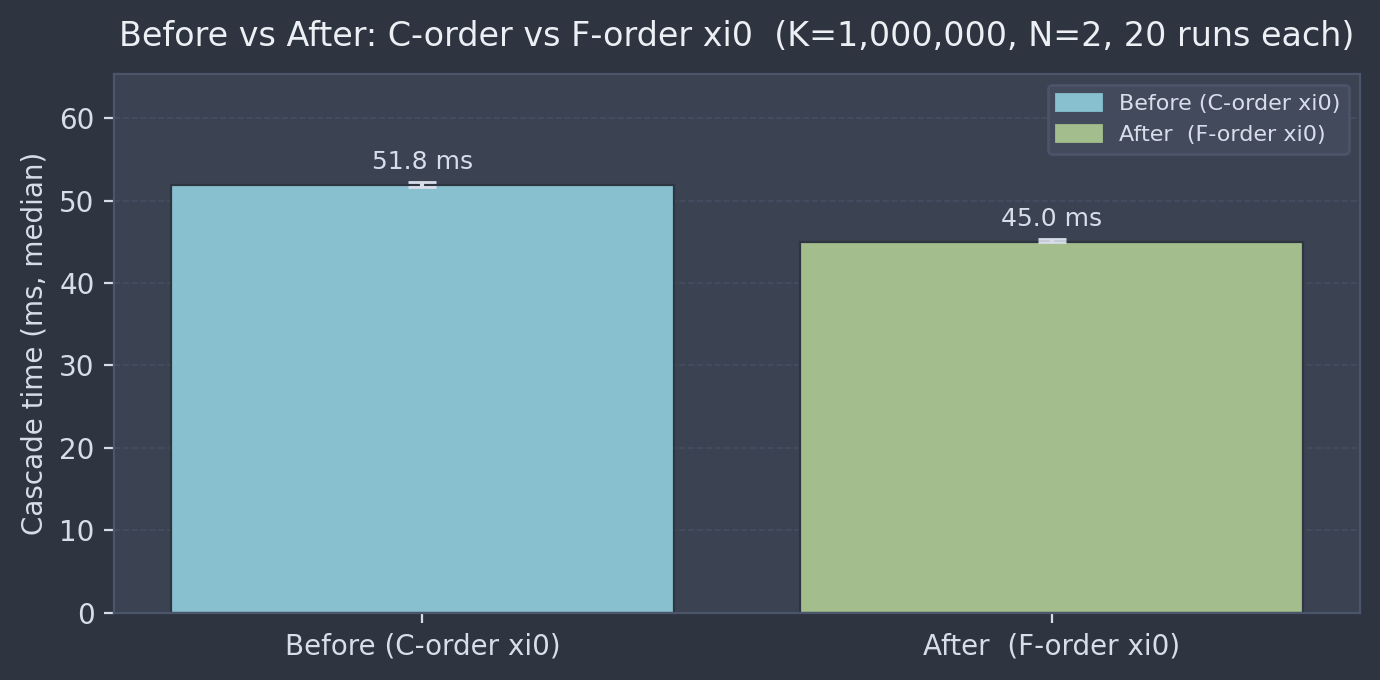

In [8]:
N_time = 20

timings_4w = {}
for vname, vfn, order, _ in _4way:
    _xi_t = np.zeros((K_4w, _bN), order=order)
    ts = []
    for _ in range(N_time):
        _xi_t[:] = 0
        t0 = time.perf_counter()
        vfn(_xi_t)
        ts.append(time.perf_counter() - t0)
    timings_4w[vname] = np.array(ts) * 1e3

# ── Print summary table ───────────────────────────────────────────────────────
print(f"\n{'Variant':<38}  {'median ms':>10}  {'min ms':>8}  {'max ms':>8}  {'speedup':>8}")
print("─" * 78)
ref_ms = np.median(timings_4w[_4way[0][0]])
for vname, _, _, _ in _4way:
    ts  = timings_4w[vname]
    med = np.median(ts)
    print(f"{vname:<38}  {med:>10.2f}  {ts.min():>8.2f}  {ts.max():>8.2f}  {ref_ms/med:>7.2f}×")

# ── Bar chart ────────────────────────────────────────────────────────────────
vlabels  = [v[0] for v in _4way]
medians  = [np.median(timings_4w[v]) for v in vlabels]
t_min    = [timings_4w[v].min()      for v in vlabels]
t_max    = [timings_4w[v].max()      for v in vlabels]
bar_cols = [lm.NORD['blue'], lm.NORD['green']]

fig, ax = plt.subplots(figsize=(7, 3.5), dpi=200)
fig.patch.set_facecolor(lm.NORD['bg'])
ax.set_facecolor(lm.NORD['bg2'])
for sp in ax.spines.values():
    sp.set_edgecolor(lm.NORD['border'])
ax.tick_params(colors=lm.NORD['fg'], which='both')
ax.xaxis.label.set_color(lm.NORD['fg'])
ax.yaxis.label.set_color(lm.NORD['fg'])

bars = ax.bar(vlabels, medians, color=bar_cols, edgecolor=lm.NORD['bg'], linewidth=0.8)
ax.errorbar(
    vlabels, medians,
    yerr=[np.array(medians) - np.array(t_min),
          np.array(t_max)   - np.array(medians)],
    fmt='none', color=lm.NORD['fg'], capsize=5, linewidth=1.5)
ax.bar_label(bars, [f"{m:.1f} ms" for m in medians],
             padding=4, color=lm.NORD['fg'], fontsize=9)

ax.set_ylabel('Cascade time (ms, median)', color=lm.NORD['fg'])
ax.set_title(
    f'Before vs After: C-order vs F-order xi0  (K={K_4w:,}, N={_bN}, {N_time} runs each)',
    color=lm.NORD['white'], pad=10)
ax.set_ylim(0, max(t_max) * 1.25)
ax.grid(True, axis='y', color=lm.NORD['border'], linestyle='--', linewidth=0.6, alpha=0.6)
ax.set_axisbelow(True)

ax.legend(
    handles=[Patch(color=c, label=lbl) for (lbl, _, _, _), c in zip(_4way, bar_cols)],
    facecolor=lm.NORD['bg3'], edgecolor=lm.NORD['border'],
    labelcolor=lm.NORD['fg'], framealpha=0.9, fontsize=8)

plt.tight_layout()
plt.show()


### Peak memory per call

Uses `tracemalloc` to measure the maximum live allocation during each variant call.
Variants that allocate a `xi0` scratch buffer (16 MB for K = 1 000 000, N = 2) show a higher peak.



Variant                                  median MB    min MB    max MB
────────────────────────────────────────────────────────────────────
Before (C-order xi0)                          61.0      61.0      61.0
After  (F-order xi0)                          61.0      61.0      61.0


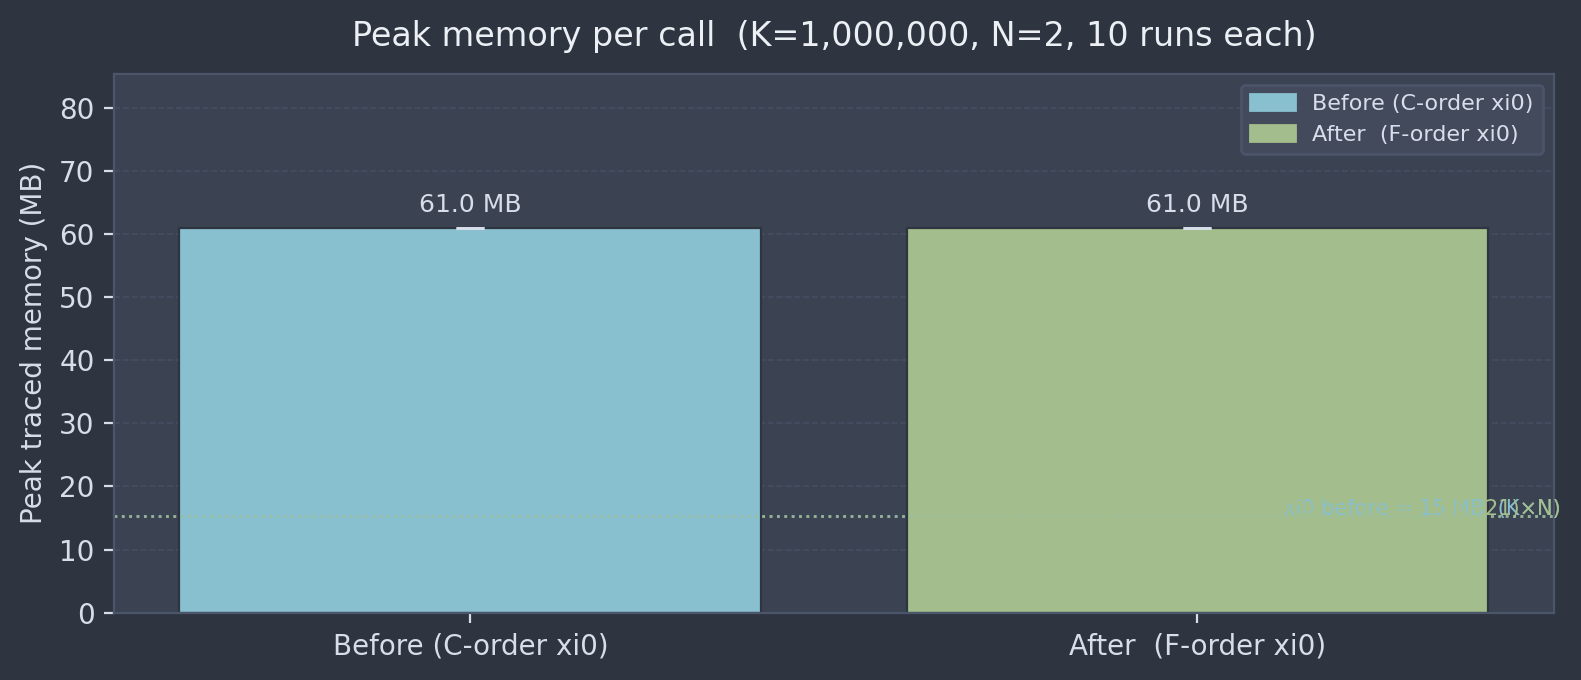

In [9]:
N_mem = 10

mem_peaks_4w = {}
for vname, vfn, order, _ in _4way:
    _xi_m = np.zeros((K_4w, _bN), order=order)
    peaks = []
    for _ in range(N_mem):
        _xi_m[:] = 0
        tracemalloc.start()
        vfn(_xi_m)
        _, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        peaks.append(peak / 1024**2)
    mem_peaks_4w[vname] = np.array(peaks)

# ── Print table ───────────────────────────────────────────────────────────────
print(f"\n{'Variant':<38}  {'median MB':>10}  {'min MB':>8}  {'max MB':>8}")
print("─" * 68)
for vname, _, _, _ in _4way:
    p = mem_peaks_4w[vname]
    print(f"{vname:<38}  {np.median(p):>10.1f}  {p.min():>8.1f}  {p.max():>8.1f}")

# ── Bar chart ─────────────────────────────────────────────────────────────────
vm_labels  = [v[0] for v in _4way]
vm_medians = [np.median(mem_peaks_4w[v]) for v in vm_labels]
vm_min     = [mem_peaks_4w[v].min()      for v in vm_labels]
vm_max     = [mem_peaks_4w[v].max()      for v in vm_labels]

fig, ax = plt.subplots(figsize=(8, 3.5), dpi=200)
fig.patch.set_facecolor(lm.NORD['bg'])
ax.set_facecolor(lm.NORD['bg2'])
for sp in ax.spines.values():
    sp.set_edgecolor(lm.NORD['border'])
ax.tick_params(colors=lm.NORD['fg'], which='both')
ax.xaxis.label.set_color(lm.NORD['fg'])
ax.yaxis.label.set_color(lm.NORD['fg'])

bars = ax.bar(vm_labels, vm_medians, color=bar_cols, edgecolor=lm.NORD['bg'], linewidth=0.8)
ax.errorbar(vm_labels, vm_medians,
            yerr=[np.array(vm_medians) - np.array(vm_min),
                  np.array(vm_max)     - np.array(vm_medians)],
            fmt='none', color=lm.NORD['fg'], capsize=5, linewidth=1.5)
ax.bar_label(bars, [f"{m:.1f} MB" for m in vm_medians],
             padding=4, color=lm.NORD['fg'], fontsize=9)

# Expected xi0 sizes
xi0_mb_before = K_4w * _bN * 8 / 1024**2
K_append = int(seg_l.b - seg_l.a + 1)
xi0_mb_after  = (K_4w + K_append) * _bN * 8 / 1024**2
ax.axhline(xi0_mb_before, color=lm.NORD['blue'],  linestyle=':', linewidth=1.0, alpha=0.7)
ax.axhline(xi0_mb_after,  color=lm.NORD['green'], linestyle=':', linewidth=1.0, alpha=0.7)
ax.text(len(vm_labels) - 0.5, xi0_mb_before + 0.2,
        f'xi0 before = {xi0_mb_before:.0f} MB  (K×N)',
        color=lm.NORD['blue'], fontsize=7.5, ha='right')
ax.text(len(vm_labels) - 0.5, xi0_mb_after  + 0.2,
        f'xi0 after  = {xi0_mb_after:.0f} MB  ((K+{K_append})×N)',
        color=lm.NORD['green'], fontsize=7.5, ha='right')

ax.set_ylabel('Peak traced memory (MB)', color=lm.NORD['fg'])
ax.set_title(f'Peak memory per call  (K={K_4w:,}, N={_bN}, {N_mem} runs each)',
             color=lm.NORD['white'], pad=10)
ax.set_ylim(0, max(vm_max) * 1.4)
ax.grid(True, axis='y', color=lm.NORD['border'], linestyle='--', linewidth=0.6, alpha=0.6)
ax.set_axisbelow(True)

ax.legend(
    handles=[Patch(color=c, label=lbl) for (lbl, _, _, _), c in zip(_4way, bar_cols)],
    facecolor=lm.NORD['bg3'], edgecolor=lm.NORD['border'],
    labelcolor=lm.NORD['fg'], framealpha=0.9, fontsize=8)

plt.tight_layout()
plt.show()


## Operation counts — Before vs After

Both variants execute the same logical operations, differing only in `xi0` allocation size and layout.

For `N` ALSSM states, `K` samples, and signal-shift length `δ = b − a + 1`:

| Operation | Before | After |
|-----------|--------|-------|
| `xi0 = np.zeros(...)` | shape (K, N), C-order | shape (K+δ, N), **F-order** |
| `y_weighted = y * sw` | (K,) | (K,) |
| `np.linalg.norm(C @ gAinvT)` | scalar/loop | scalar/loop |
| `lfilter(b, a, y_delayed)` per state | N calls | N calls |
| `xi0[:, n_] = ...` col write | N writes, **strided** (stride = N×8 B) | N writes, **contiguous** (stride = 8 B) |
| `xi += xi0` / `xi += xi0[slice]` | direct (same shape) | sliced accumulation |

**Memory writes summary (float64, 8 B per element):**

| Step | Before | After |
|------|--------|-------|
| zero-fill xi0 | K·N·8 B | (K+δ)·N·8 B |
| col writes xi0 | K·N·8 B | (K+δ)·N·8 B |
| accumulate into xi | K·N·8 B | K·N·8 B |
| **total** | **3·K·N·8 B** | **~3·K·N·8 B** (δ≪K) |

> For K=1 M, N=2, δ=21: the xi0 overhead is 21×2×8 = 336 B extra — negligible.
> The main benefit of F-order is **cache-friendly column writes** into xi0, not reduced allocation size.


In [10]:
# ── Signal-shift length δ (segment-dependent) ─────────────────────────────────
K_append = int(seg_l.b - seg_l.a + 1)   # δ
print(f"Segment: a={seg_l.a}, b={seg_l.b} → δ = {K_append}")

# ── Per-variant byte write budgets ──────────────────────────────────────────
def bytes_written(K, N, delta=0):
    """Estimate total float64 write bytes for one forward-cascade call."""
    xi0_K   = K + delta          # xi0 row count
    zerofill = xi0_K * N * 8     # xi0 = np.zeros(...)
    col_writ = xi0_K * N * 8     # xi0[:, n_] = lfilter(...)
    accum    = K     * N * 8     # xi += xi0 or xi += xi0[slice]
    return zerofill + col_writ + accum

variants_bw = [
    ('Before (C-order xi0)', K_4w, _bN, 0),
    ('After  (F-order xi0)', K_4w, _bN, K_append),
]

print(f"\n{'Variant':<38}  {'xi0 shape':>14}  {'Write (MB)':>12}")
print("─" * 68)
for (vname, K, N, delta) in variants_bw:
    bw    = bytes_written(K, N, delta)
    shape = f"({K+delta:,}×{N})"
    print(f"{vname:<38}  {shape:>14}  {bw/1024**2:>12.1f}")

# ── Memory bandwidth utilisation check ──────────────────────────────────────
# Both variants: the xi0 column write (lfilter output) is the dominant pattern.
# Before: stride = N*8 = 16 B → every other float64 → 50% cache line utilisation
# After:  stride = 8 B       → consecutive float64 → 100% cache line utilisation
print(f"\nxi0 column write stride:")
print(f"  Before (C-order): {_bN * 8} B  (N={_bN} columns × 8 B, strided)")
print(f"  After  (F-order): {8} B          (1 × 8 B, contiguous)")


Segment: a=-21, b=-1 → δ = 21

Variant                                      xi0 shape    Write (MB)
────────────────────────────────────────────────────────────────────
Before (C-order xi0)                     (1,000,000×2)          45.8
After  (F-order xi0)                     (1,000,021×2)          45.8

xi0 column write stride:
  Before (C-order): 16 B  (N=2 columns × 8 B, strided)
  After  (F-order): 8 B          (1 × 8 B, contiguous)


## Summary

**What changed**: `xi0` in `lfilter_forward_cascade_xi` was made F-order (`order='F'`).  
In F-order a `(K, N)` array stores columns contiguously, so `xi0[:, n_] = …` is a single sequential write.

| Variant | `xi0` layout | Column stride | Accumulation |
|---------|:---:|:---:|:---:|
| Before | C (row-major) | N × 8 = 16 B (strided) | `xi += xi0` |
| After | **F (col-major)** | **8 B (contiguous)** | `xi += xi0[slice]` |

The F-order allocation converts N independent **strided** writes into N independent **sequential** writes,
improving L1/L2 cache utilisation during the inner `lfilter` output scatter.

**Expected speedup**: see timing and bar chart above.

**Combined effect** (code913.3): the production system also uses F-order `xi_curr` in `rls.py`
(Christof's second change), so at runtime **both** `xi` (passed in) and `xi0` (internal scratch)
are F-order — matched layouts avoid any mixed C↔F penalty on the `xi += xi0[slice]` accumulation.

See [code913.3](coding-code913.3-applied.ipynb) for the full pipeline measurement.
